In [ ]:
#======================================================
# APPLE STOCK PRICE ANALYSIS AND PREDICTION MSC-PROJECT
#======================================================

# ----------------
# Import Libraries
# ----------------

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
# -------------------------------------------------
# DATA COLLECTION OF APPLE STOCK FROM YAHOO FINANCE
# -------------------------------------------------

data = yf.download("AAPL", start="2015-01-01", end="2025-01-01") #downloading apple stock price from 01 Jan 2015 to 01 Jan 2025
data.reset_index(inplace=True)

print("Data Loaded:")
print(data.head()) #printing first 5 rows of the dataset

/tmp/ipykernel_3175/2148492380.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2025-01-01") #downloading apple stock price from 01 Jan 2015 to 01 Jan 2025
[*********************100%***********************]  1 of 1 completed

Data Loaded:
Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2015-01-02  24.192602  24.659504  23.754466  24.648440  212818400
1      2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2      2015-01-06  23.513273  23.772171  23.152585  23.575232  263188400
3      2015-01-07  23.842976  23.942551  23.610630  23.721271  160423600
4      2015-01-08  24.759089  24.816622  24.053203  24.170483  237458000


In [ ]:
# ---------------------------
# DATA CLEANING/PREPROCESSING
# ---------------------------


data.reset_index(inplace=True)

new_columns = []
for col_name in data.columns:
    if isinstance(col_name, tuple):

        if col_name[1] == '':
            new_columns.append(col_name[0])
        else:
            new_columns.append(col_name[0]) # We just want the metric name, not the ticker.
    else:
        new_columns.append(str(col_name))
data.columns = new_columns


# CHECK DATA INFORMATION
print("Initial Data Information:")
print(data.info())

print("\nFirst 5 Rows:")
print(data.head())

# CHECK MISSING VALUES
print("\nMissing Values Before Cleaning:")
print(data.isnull().sum())

# REMOVE DUPLICATES
data = data.drop_duplicates()

print("\nDuplicate Rows Removed")

# CONVERT DATE COLUMN
data['Date'] = pd.to_datetime(data['Date'])

# SORT DATA BY DATE
data = data.sort_values(by='Date')

# HANDLE MISSING VALUES

# Forward fill missing values
data = data.ffill()

# Backward fill remaining missing values (optional)
data = data.bfill()

# CHECK DATA TYPES
print("\nData Types:")
print(data.dtypes)

# CONVERT NUMERIC COLUMNS
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')



Initial Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   level_0  2516 non-null   int64         
 1   index    2516 non-null   int64         
 2   Date     2516 non-null   datetime64[ns]
 3   Close    2516 non-null   float64       
 4   High     2516 non-null   float64       
 5   Low      2516 non-null   float64       
 6   Open     2516 non-null   float64       
 7   Volume   2516 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 157.4 KB
None

First 5 Rows:
   level_0  index       Date      Close       High        Low       Open  \
0        0      0 2015-01-02  24.192602  24.659504  23.754466  24.648440   
1        1      1 2015-01-05  23.511063  24.042136  23.325188  23.962475   
2        2      2 2015-01-06  23.513273  23.772171  23.152585  23.575232   
3        3      3 2015-

In [ ]:
# -------------------
# FEATURE ENGINEERING
# -------------------

# 20 Days Moving Average Claculation
data['MA20'] = data['Close'].rolling(window=20).mean()

# 50 Days Moving Average Calculation
data['MA50'] = data['Close'].rolling(window=50).mean()

# Daily Returns Claculation
data['Returns'] = data['Close'].pct_change()


# HANDLE NEW NaN VALUES CREATED BY FEATURES
data = data.dropna()

# CHECK FOR OUTLIERS (OPTIONAL)
print("\nStatistical Summary:")
print(data.describe())

# FINAL MISSING VALUE CHECK
print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

# CREATE CLEAN DATASET

# It's possible there's an 'index' column from repeated reset_index.
# Let's adjust this to specifically select the desired columns.
desired_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'Returns']
stock_data = data[desired_cols]

# EXPORT CSV
stock_data.to_csv("stock_data.csv", index=False)

print("\nstock_data.csv created successfully!")

# PREVIEW CLEANED DATA HEAD
print("\nCleaned Dataset Preview:")
print(stock_data.head())


Statistical Summary:
          level_0       index                           Date        Close  \
count  2467.00000  2467.00000                           2467  2467.000000   
mean   1282.00000  1282.00000  2020-02-05 07:46:22.813133312    95.019062   
min      49.00000    49.00000            2015-03-16 00:00:00    20.565872   
25%     665.50000   665.50000            2017-08-23 12:00:00    36.108744   
50%    1282.00000  1282.00000            2020-02-06 00:00:00    67.531693   
75%    1898.50000  1898.50000            2022-07-19 12:00:00   150.963142   
max    2515.00000  2515.00000            2024-12-31 00:00:00   257.375610   
std     712.30588   712.30588                            NaN    65.268407   

              High          Low         Open        Volume         MA20  \
count  2467.000000  2467.000000  2467.000000  2.467000e+03  2467.000000   
mean     95.941270    93.992824    94.929699  1.145220e+08    94.161940   
min      20.868639    20.367818    20.488465  2.323470e+07 

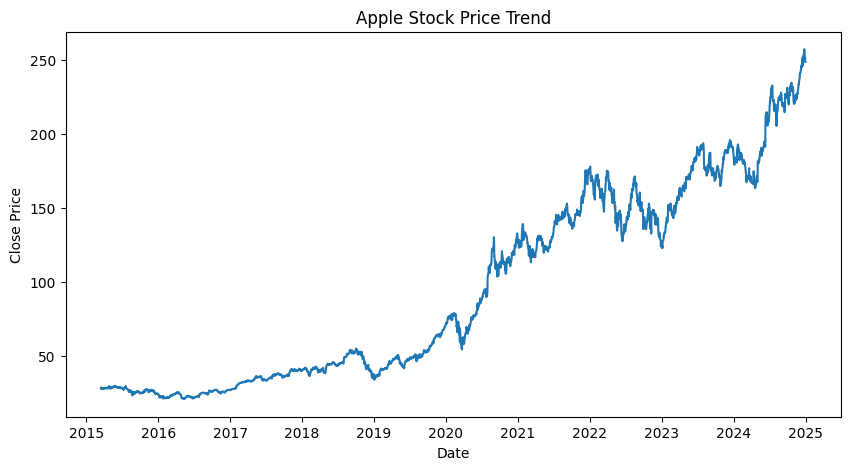

In [ ]:
# ----------------------------
# 3. EXPLORATORY DATA ANALYSIS
# ----------------------------

plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['Close'])
plt.title("Apple Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

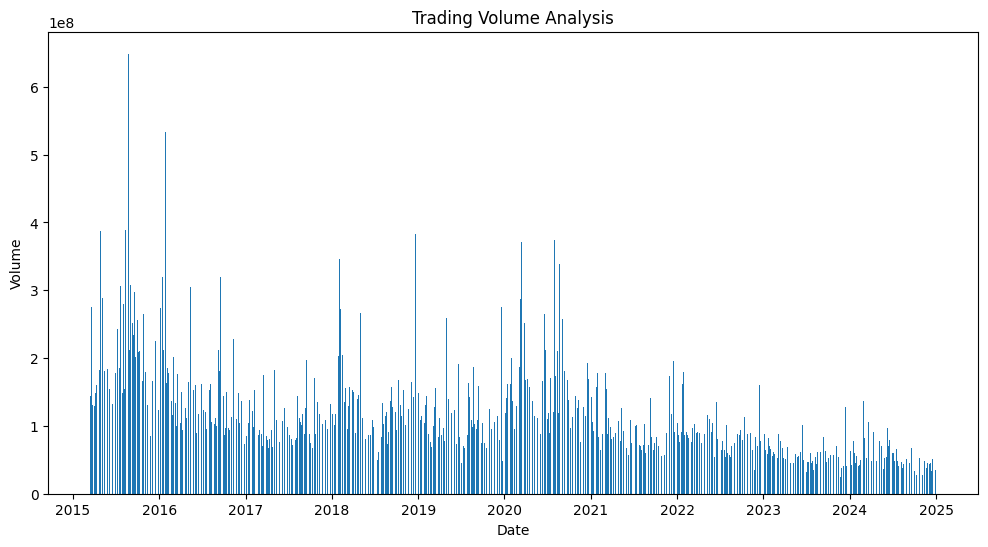

In [ ]:
#VOLUME ANALYSIS
plt.figure(figsize=(12,6))

plt.bar(data['Date'],
        data['Volume'])

plt.title("Trading Volume Analysis")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

In [ ]:
print(data.describe())

          level_0       index                           Date        Close  \
count  2467.00000  2467.00000                           2467  2467.000000   
mean   1282.00000  1282.00000  2020-02-05 07:46:22.813133312    95.019062   
min      49.00000    49.00000            2015-03-16 00:00:00    20.565872   
25%     665.50000   665.50000            2017-08-23 12:00:00    36.108744   
50%    1282.00000  1282.00000            2020-02-06 00:00:00    67.531693   
75%    1898.50000  1898.50000            2022-07-19 12:00:00   150.963142   
max    2515.00000  2515.00000            2024-12-31 00:00:00   257.375610   
std     712.30588   712.30588                            NaN    65.268407   

              High          Low         Open        Volume         MA20  \
count  2467.000000  2467.000000  2467.000000  2.467000e+03  2467.000000   
mean     95.941270    93.992824    94.929699  1.145220e+08    94.161940   
min      20.868639    20.367818    20.488465  2.323470e+07    21.366901   
25%   

In [ ]:
# -----------------------
# LINEAR REGRESSION MODEL
# -----------------------

df_lr = data[['Date', 'Close']].copy()

# Lag feature
df_lr['Lag1'] = df_lr['Close'].shift(1)
df_lr = df_lr.dropna()

X = df_lr[['Lag1']]
y = df_lr['Close']

# Train-test split
split = int(len(df_lr) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

Linear Regression RMSE: 2.53438108344278
Linear Regression MAE: 1.8815164688279047


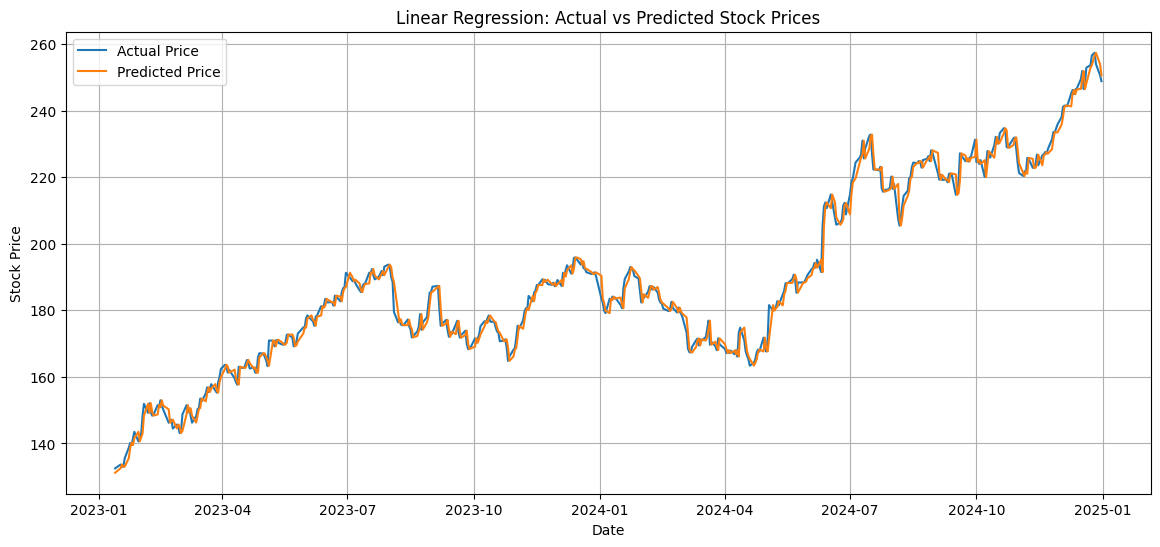

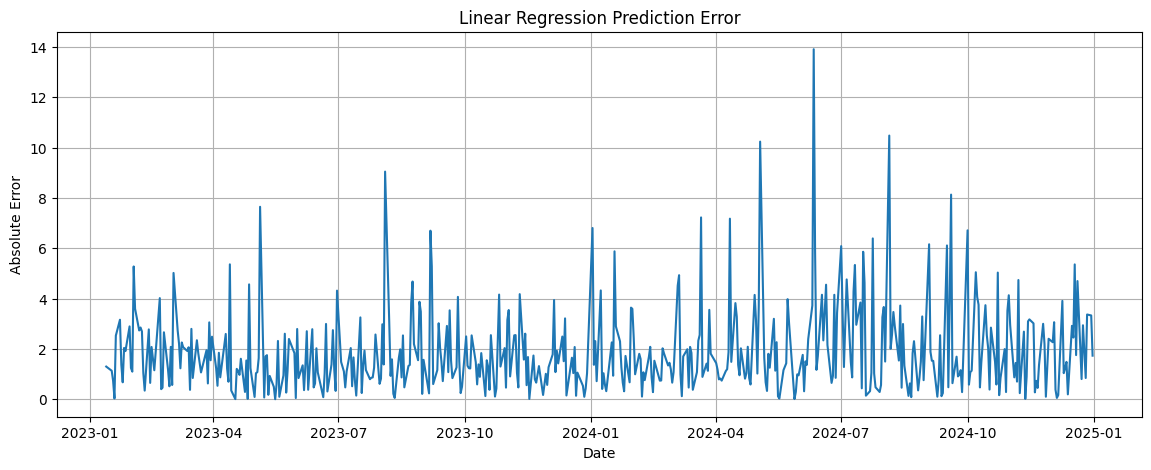

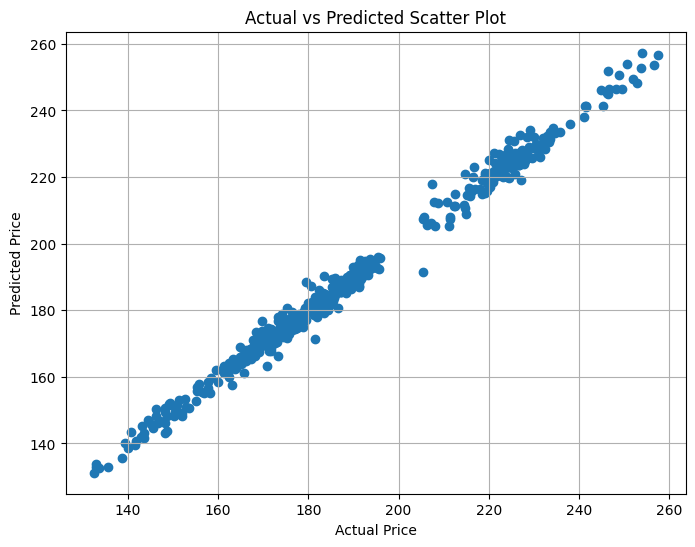

In [ ]:
# ------------------
# EVALUATION METRICS
# ------------------

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

#--------------
# VISUALIZATION
#--------------

# VISUALIZATION ACTUAL VS PREDICTED BASED ON LINEAR REGRESSION
plt.figure(figsize=(14,6))

plt.plot(df_lr['Date'][split:], y_test,
         label='Actual Price')

plt.plot(df_lr['Date'][split:], lr_pred,
         label='Predicted Price')

plt.title('Linear Regression: Actual vs Predicted Stock Prices')

plt.xlabel('Date')

plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()

# VISUALIZATION: PREDICTION ERROR
error = abs(y_test - lr_pred)

plt.figure(figsize=(14,5))

plt.plot(df_lr['Date'][split:], error)

plt.title('Linear Regression Prediction Error')

plt.xlabel('Date')

plt.ylabel('Absolute Error')

plt.grid(True)

plt.show()


# VISUALIZATION: SCATTER PLOT
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.title('Actual vs Predicted Scatter Plot')

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.grid(True)

plt.show()

In [ ]:
# ----------
# LSTM MODEL
# ----------

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Close']])

# Create sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X_lstm, y_lstm = create_sequences(scaled_data, seq_length)

# Train-test split
split_lstm = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split_lstm], X_lstm[split_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:split_lstm], y_lstm[split_lstm:]

# Build model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train_lstm.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=32)

# Predict
lstm_pred = model.predict(X_test_lstm)

# Inverse transform
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test_lstm)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0122
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.1945e-04
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.7714e-04
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 2.5265e-04
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.2818e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


LSTM RMSE: 5.32688918159111
LSTM MAE: 4.227273521581626


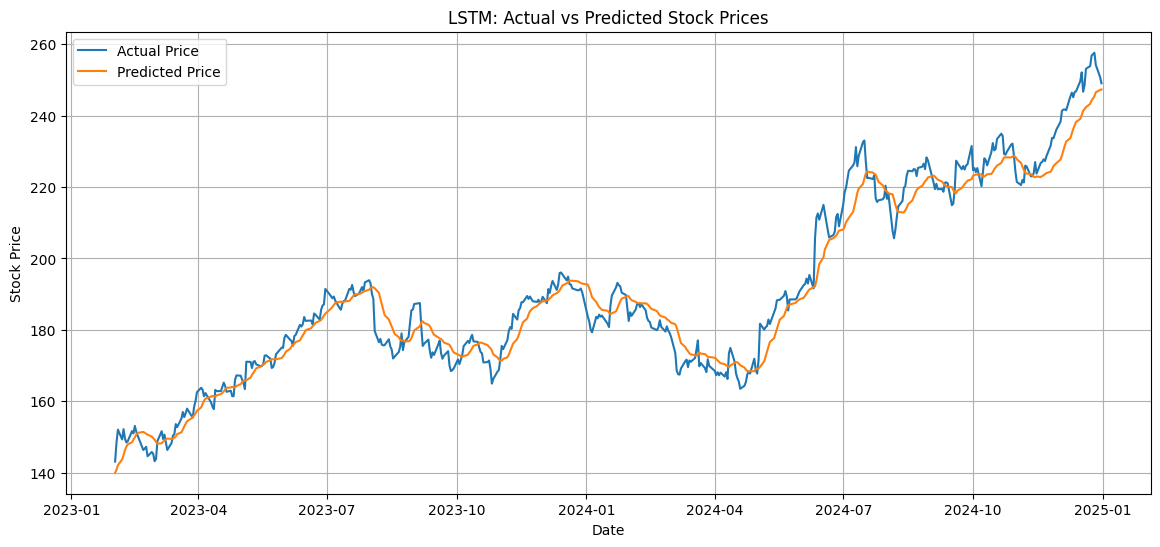

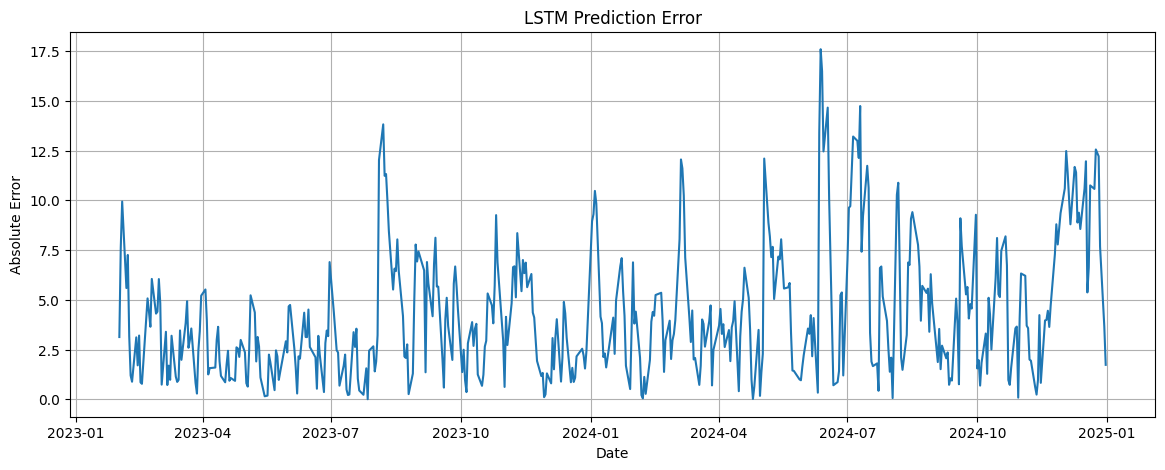

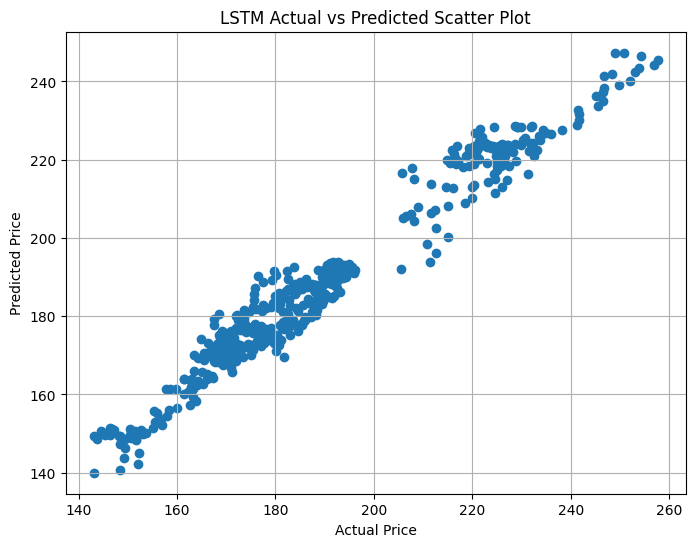

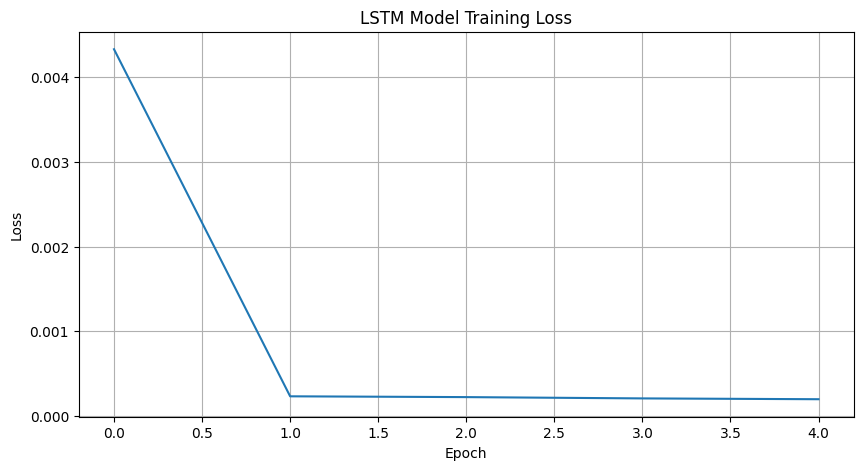

In [ ]:
# ------------------
# EVALUATION METRICS
# ------------------

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)

# ---------------------------------
# VISUALIZATION BASED ON LSTM MODEL
# ---------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    data['Date'][-len(y_test_actual):],
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    data['Date'][-len(lstm_pred):],
    lstm_pred,
    label='Predicted Price'
)

plt.title('LSTM: Actual vs Predicted Stock Prices')

plt.xlabel('Date')

plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()


# VISUALIZATION: PREDICTION ERROR
lstm_error = abs(y_test_actual.flatten() - lstm_pred.flatten())

plt.figure(figsize=(14,5))

plt.plot(
    data['Date'][-len(lstm_error):],
    lstm_error
)

plt.title('LSTM Prediction Error')

plt.xlabel('Date')

plt.ylabel('Absolute Error')

plt.grid(True)

plt.show()

# VISUALIZATION SCATTER PLOT

plt.figure(figsize=(8,6))

plt.scatter(y_test_actual, lstm_pred)

plt.title('LSTM Actual vs Predicted Scatter Plot')

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.grid(True)

plt.show()

# VISUALIZATION: LOSS CURVE

plt.figure(figsize=(10,5))

plt.plot(model.history.history['loss'])

plt.title('LSTM Model Training Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.grid(True)

plt.show()

In [ ]:
# ----------------
# MODEL EVALUATION
# ----------------

# Linear Regression Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

# LSTM Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

print("\n--- Model Performance ---")
print(f"Linear Regression RMSE: {lr_rmse}")
print(f"Linear Regression MAE: {lr_mae}")
print(f"LSTM RMSE: {lstm_rmse}")
print(f"LSTM MAE: {lstm_mae}")


--- Model Performance ---
Linear Regression RMSE: 2.5367152598642777
Linear Regression MAE: 1.8832487285646144
LSTM RMSE: 7.695244208155366
LSTM MAE: 6.078338243160011


In [ ]:
# ----------------------
# CREATE predictions.csv
# ----------------------

# Align dates for LSTM
lstm_dates = data['Date'].iloc[-len(lstm_pred):].reset_index(drop=True)

predictions_df = pd.DataFrame({
    'Date': lstm_dates,
    'Actual Price': y_test_actual.flatten(),
    'Predicted Price (LSTM)': lstm_pred.flatten()
})

# Add Linear Regression predictions (trim if needed)
predictions_df['Predicted Price (Linear Regression)'] = lr_pred[:len(predictions_df)]

# Save file
predictions_df.to_csv("predictions.csv", index=False)

print("predictions.csv created!")

predictions.csv created!


In [ ]:
print("\nFirst 5 Rows of predictions_df:")
print(predictions_df.head())



First 5 Rows of predictions_df:
        Date  Actual Price  Predicted Price (LSTM)  \
0 2023-02-01    143.134674              137.645721   
1 2023-02-02    148.439621              138.602432   
2 2023-02-03    152.061523              139.688141   
3 2023-02-06    149.335236              140.968704   
4 2023-02-07    152.209152              142.239166   

   Predicted Price (Linear Regression)  
0                           131.328707  
1                           132.656770  
2                           133.817630  
3                           133.099463  
4                           133.158517  


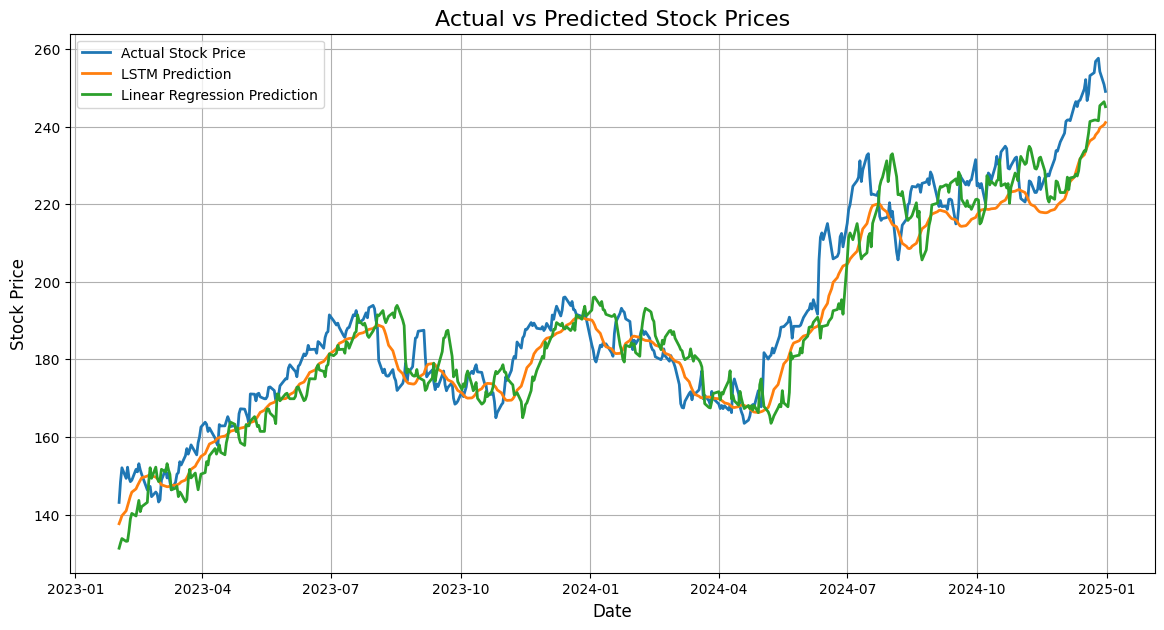

In [ ]:
# -----------------------------------------------------
# FINAL VISUALIZATION: ACTUAL VS PREDICTED STOCK PRICES
# -----------------------------------------------------

# Import visualization library
import matplotlib.pyplot as plt

# -------------
# CREATE FIGURE
# -------------

# figsize controls chart size
# (width = 14 inches, height = 7 inches)

plt.figure(figsize=(14,7))

# --------------------------
# PLOT 1: ACTUAL STOCK PRICE
# --------------------------

# X-axis  -> Date
# Y-axis  -> Actual Price

plt.plot(
    predictions_df['Date'],
    predictions_df['Actual Price'],
    label='Actual Stock Price',
    linewidth=2
)

# --------------------------------------------
# WHY THIS IS IMPORTANT
# --------------------------------------------

# This line represents the REAL stock prices.
# It acts as the benchmark for evaluating
# machine learning predictions.

# -----------------------
# PLOT 2: LSTM PREDICTION
# -----------------------

plt.plot(
    predictions_df['Date'],
    predictions_df['Predicted Price (LSTM)'],
    label='LSTM Prediction',
    linewidth=2
)

# --------------------------------------------
# WHY THIS IS IMPORTANT
# --------------------------------------------

# This line shows prices predicted by the
# LSTM deep learning model.

# By comparing this line with the actual
# stock price line, we can visually assess:
# - Prediction accuracy
# - Trend-following capability
# - Error patterns

# ------------------------------------
# PLOT 3: LINEAR REGRESSION PREDICTION
# ------------------------------------

plt.plot(
    predictions_df['Date'],
    predictions_df['Predicted Price (Linear Regression)'],
    label='Linear Regression Prediction',
    linewidth=2
)

# --------------------------------------------
# WHY THIS IS IMPORTANT
# --------------------------------------------

# This line shows predictions generated by
# the Linear Regression model.

# It helps compare:
# - Traditional ML approach
# vs
# - Deep learning approach (LSTM)

# -----------
# CHART TITLE
# -----------

plt.title(
    'Actual vs Predicted Stock Prices',
    fontsize=16
)

# --------------------------------------------
# WHY TITLE IS IMPORTANT
# --------------------------------------------

# A proper title improves readability and
# clearly communicates the purpose of
# the visualization.

# ------------
# X-AXIS LABEL
# ------------

plt.xlabel(
    'Date',
    fontsize=12
)

# --------------------------------------------
# WHY X-AXIS LABEL IS IMPORTANT
# --------------------------------------------

# Indicates that the data is time-series data.

# ------------
# Y-AXIS LABEL
# ------------

plt.ylabel(
    'Stock Price',
    fontsize=12
)

# --------------------------------------------
# WHY Y-AXIS LABEL IS IMPORTANT
# --------------------------------------------

# Shows that the vertical axis represents
# stock price values.

# ------
# LEGEND
# ------

plt.legend()

# --------------------------------------------
# WHY LEGEND IS IMPORTANT
# --------------------------------------------

# The legend identifies:
# - Actual stock prices
# - LSTM predictions
# - Linear Regression predictions

# This makes the chart easy to interpret.

# ----
# GRID
# ----

plt.grid(True)

# --------------------------------------------
# WHY GRID IS IMPORTANT
# --------------------------------------------

# Grid lines improve readability and help
# compare values across dates.

# -------------
# DISPLAY CHART
# -------------

plt.show()

# --------------------------------------------
# FINAL PURPOSE OF THIS VISUALIZATION
# --------------------------------------------

# This visualization is used to:
# 1. Compare actual and predicted prices
# 2. Evaluate model performance visually
# 3. Identify which model follows trends better
# 4. Detect large deviations or errors
# 5. Support analytical conclusions in the report